In [1]:
print("TASK 1 \n")
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("students_feature_engineered_v2.csv")
X = df.drop(columns=["Pass"])
y = df["Pass"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y) 
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)
base_acc = accuracy_score(y_test, model.predict(X_test))
print(f"Accuracy on X_test: {base_acc:.3f}")

seeds = [0, 7, 13, 21, 99]
scores = []
for seed in seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=seed, stratify=y)
    mdl= LogisticRegression(max_iter=500)
    mdl.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, mdl.predict(X_te))
    scores.append(acc)
    print(f"Seed {seed} accuracy: {acc:.3f}")
    
score_range = max(scores) - min(scores)
print(f"Score range: {score_range:.3f}")

X_tr_final, X_val, y_tr_final, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=42)
print("Train shape:", X_tr_final.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)
    


TASK 1 

Accuracy on X_test: 1.000
Seed 0 accuracy: 1.000
Seed 7 accuracy: 1.000
Seed 13 accuracy: 1.000
Seed 21 accuracy: 1.000
Seed 99 accuracy: 1.000
Score range: 0.000
Train shape: (640, 6)
Val shape: (160, 6)
Test shape: (200, 6)


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("TASK 2\n")
X_arr = X.values
y_arr = y.values

# Plain KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_scores_kf = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_arr), start=1):
    X_tr, X_val = X_arr[train_idx], X_arr[val_idx]
    y_tr, y_val = y_arr[train_idx], y_arr[val_idx]
    
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)
    
    model = LogisticRegression(max_iter=500)
    model.fit(X_tr, y_tr)
    acc = accuracy_score(y_val, model.predict(X_val))
    fold_scores_kf.append(acc)
    print(f"KFold Fold {fold}: {acc:.3f}")

print(f"KFold Mean: {np.mean(fold_scores_kf):.3f} Std: {np.std(fold_scores_kf):.3f}\n")

# StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores_skf = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_arr, y_arr), start=1):
    X_tr, X_val = X_arr[train_idx], X_arr[val_idx]
    y_tr, y_val = y_arr[train_idx], y_arr[val_idx]
    
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)
    
    model = LogisticRegression(max_iter=500)
    model.fit(X_tr, y_tr)
    acc = accuracy_score(y_val, model.predict(X_val))
    fold_scores_skf.append(acc)
    print(f"StratifiedKFold Fold {fold}: {acc:.3f}")

print(f"StratifiedKFold Mean: {np.mean(fold_scores_skf):.3f} Std: {np.std(fold_scores_skf):.3f}")

TASK 2

KFold Fold 1: 1.000
KFold Fold 2: 1.000
KFold Fold 3: 1.000
KFold Fold 4: 1.000
KFold Fold 5: 1.000
KFold Mean: 1.000 Std: 0.000

StratifiedKFold Fold 1: 1.000
StratifiedKFold Fold 2: 1.000
StratifiedKFold Fold 3: 1.000
StratifiedKFold Fold 4: 1.000
StratifiedKFold Fold 5: 1.000
StratifiedKFold Mean: 1.000 Std: 0.000


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, cross_validate

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=500))
])

print("TASK 3\n")
# Step 2
scores_acc = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
print("Accuracy per fold:", scores_acc.round(3))
print(f"Mean Accuracy: {scores_acc.mean():.3f} (+/- {scores_acc.std():.3f})")

# Step 3
scores_f1 = cross_val_score(pipe, X, y, cv=5, scoring="f1")
print(f"Mean F1 Score: {scores_f1.mean():.3f}")

# Step 4
cv_results = cross_validate(pipe, X, y, cv=5, scoring=["accuracy", "f1"], return_train_score=True)
for key, vals in cv_results.items():
    print(f"{key:30s}: {vals.round(3)}")

TASK 3

Accuracy per fold: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.000 (+/- 0.000)
Mean F1 Score: 1.000
fit_time                      : [0.018 0.014 0.015 0.018 0.014]
score_time                    : [0.012 0.012 0.014 0.008 0.007]
test_accuracy                 : [1. 1. 1. 1. 1.]
train_accuracy                : [1. 1. 1. 1. 1.]
test_f1                       : [1. 1. 1. 1. 1.]
train_f1                      : [1. 1. 1. 1. 1.]


In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

print("TASK 4\n")
models = {
    "LogisticRegression": LogisticRegression(max_iter=500),
    "DecisionTree_full": DecisionTreeClassifier(max_depth=None, random_state=42),
    "DecisionTree_depth3": DecisionTreeClassifier(max_depth=3, random_state=42)
}

X = df.drop(columns=["Pass"])
y = df["Pass"]

rows = []
for name, clf in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    cv = cross_validate(pipe, X, y, cv=5, scoring="accuracy", return_train_score=True)
    rows.append({
        "Model": name,
        "Mean_Train": cv["train_score"].mean(),
        "Mean_Test": cv["test_score"].mean(),
        "Gap": cv["train_score"].mean() - cv["test_score"].mean()
    })

print(pd.DataFrame(rows).round(3))

TASK 4

                 Model  Mean_Train  Mean_Test  Gap
0   LogisticRegression         1.0        1.0  0.0
1    DecisionTree_full         1.0        1.0  0.0
2  DecisionTree_depth3         1.0        1.0  0.0


In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(random_state=42))
])

param_grid = {
    "clf__max_depth": [2, 3, 4, 5, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__criterion": ["gini", "entropy"]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1, refit=True)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.3f}")

results_df = pd.DataFrame(grid.cv_results_)
cols = ["param_clf__max_depth", "param_clf__min_samples_split", "mean_test_score", "std_test_score", "rank_test_score"]
print(results_df[cols].sort_values("rank_test_score").head(5))

y_pred = grid.best_estimator_.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))

Best params: {'clf__criterion': 'gini', 'clf__max_depth': 2, 'clf__min_samples_split': 2}
Best CV accuracy: 1.000
  param_clf__max_depth  param_clf__min_samples_split  mean_test_score  \
0                    2                             2              1.0   
1                    2                             5              1.0   
2                    2                            10              1.0   
3                    3                             2              1.0   
4                    3                             5              1.0   

   std_test_score  rank_test_score  
0             0.0                1  
1             0.0                1  
2             0.0                1  
3             0.0                1  
4             0.0                1  
Test accuracy: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        68
           1       1.00      1.00      1.00       132

    accuracy                           1

In [7]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

print("PART B: HW 2 \n")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

pipe_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=42))
])

param_dist = {
    "clf__n_estimators": randint(50, 300),
    "clf__max_depth": [3, 4, 5, 6, None],
    "clf__max_features": uniform(0.3, 0.7),
    "clf__min_samples_leaf": randint(1, 10)
}

rand_search = RandomizedSearchCV(pipe_rf, param_distributions=param_dist, n_iter=40, cv=5, scoring="accuracy", n_jobs=-1, random_state=42, refit=True)
rand_search.fit(X_train, y_train)

print("Best params:", rand_search.best_params_)
print(f"Best CV accuracy: {rand_search.best_score_:.3f}")

y_pred_rf = rand_search.best_estimator_.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")

PART B: HW 2 

Best params: {'clf__max_depth': 6, 'clf__max_features': np.float64(0.9655000144869412), 'clf__min_samples_leaf': 8, 'clf__n_estimators': 238}
Best CV accuracy: 1.000
Test accuracy: 1.000


HW 3 

KFold k=3 -> Mean: 1.000, Std: 0.000
KFold k=5 -> Mean: 1.000, Std: 0.000
KFold k=10 -> Mean: 1.000, Std: 0.000
StratifiedKFold k=5 -> Mean: 1.000, Std: 0.000


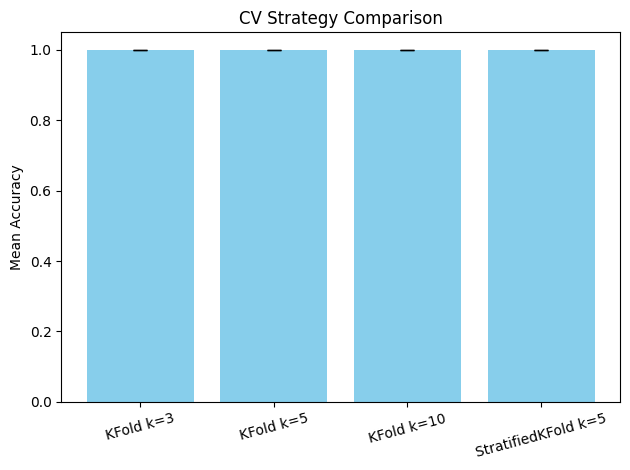

In [8]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt

print("HW 3 \n")
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(max_depth=3, random_state=42))
])

configs = [
    ("KFold k=3", KFold(n_splits=3, shuffle=True, random_state=42)),
    ("KFold k=5", KFold(n_splits=5, shuffle=True, random_state=42)),
    ("KFold k=10", KFold(n_splits=10, shuffle=True, random_state=42)),
    ("StratifiedKFold k=5", StratifiedKFold(n_splits=5, shuffle=True, random_state=42))
]

names = []
means = []
stds = []

for name, cv_obj in configs:
    scores = cross_val_score(pipe, X, y, cv=cv_obj, scoring="accuracy")
    names.append(name)
    means.append(scores.mean())
    stds.append(scores.std())
    print(f"{name} -> Mean: {scores.mean():.3f}, Std: {scores.std():.3f}")

plt.bar(names, means, yerr=stds, capsize=5, color="skyblue")
plt.ylabel("Mean Accuracy")
plt.title("CV Strategy Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("cv_comparison.png")
plt.show()

In [10]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import randint, uniform
import pandas as pd

wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target)

# Step 1: Split
X_train, X_test, y_train, y_test = train_test_split(X_wine, y_wine, test_size=0.20, random_state=42, stratify=y_wine)

# Step 2: Baseline CV
pipe_lr = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000))])
scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=5, scoring="accuracy")
print(f"Baseline CV: {scores_lr.mean():.3f} +/- {scores_lr.std():.3f}")

# Step 3: Overfitting check
pipe_dt_raw = Pipeline([("scaler", StandardScaler()), ("clf", DecisionTreeClassifier(max_depth=None, random_state=42))])
cv_dt_raw = cross_validate(pipe_dt_raw, X_train, y_train, cv=5, scoring="accuracy", return_train_score=True)
print(f"Raw DT - Train: {cv_dt_raw['train_score'].mean():.3f} | Test: {cv_dt_raw['test_score'].mean():.3f}")

# Step 4: GridSearchCV on DecisionTree
pipe_dt = Pipeline([("scaler", StandardScaler()), ("clf", DecisionTreeClassifier(random_state=42))])
grid_grid = {"clf__max_depth": [2, 3, 4, 5], "clf__min_samples_split": [2, 5, 10], "clf__criterion": ["gini", "entropy"]}
grid_search = GridSearchCV(pipe_dt, grid_grid, cv=5, scoring="accuracy", n_jobs=-1, refit=True)
grid_search.fit(X_train, y_train)
print(f"Grid Best CV: {grid_search.best_score_:.3f}")

# Step 5: Randomized SearchCV on RandomForest
pipe_rf = Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(random_state=42))])
dist_grid = {"clf__n_estimators": randint(50, 200), "clf__max_depth": [3, 4, 5, None]}
rand_search = RandomizedSearchCV(pipe_rf, dist_grid, n_iter=30, cv=5, scoring="accuracy", n_jobs=-1, random_state=42, refit=True)
rand_search.fit(X_train, y_train)
print(f"Random Best CV: {rand_search.best_score_:.3f}")

# Step 6: Final evaluation on X_test (Picking the best CV score estimator)
if grid_search.best_score_ > rand_search.best_score_:
    best_estimator = grid_search.best_estimator_
else:
    best_estimator = rand_search.best_estimator_

y_pred = best_estimator.predict(X_test)
print(f"\nFinal Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 7: Save CSV
results = pd.DataFrame({"y_true": y_test.values, "y_pred": y_pred})
results["correct"] = (results["y_true"] == results["y_pred"]).astype(int)
results.to_csv("wine_predictions.csv", index=False)
misclassified = len(results) - results["correct"].sum()
print(f"Misclassified samples count: {misclassified}")

Baseline CV: 0.993 +/- 0.014
Raw DT - Train: 1.000 | Test: 0.916
Grid Best CV: 0.923
Random Best CV: 0.986

Final Test Accuracy: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Confusion Matrix:
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]
Misclassified samples count: 0
